# K nearest training Algorithm

In [1]:
import pandas as pd
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [7]:
x=df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']]
y=df['Outcome']

In [8]:
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [22]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=15)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(y_pred)
diff=pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
diff

[1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 0
 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0
 0 0 0 1 0 0]


,Actual,Predicted
285,0,1
101,0,0
581,0,0
352,0,0
726,0,0
...,...,...
563,0,0
318,0,0
154,1,1
684,0,0


In [23]:
diff.to_csv("diabetes_data.csv")

In [25]:
diff.to_excel("diabetes_data.xlsx")

In [26]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[89 10]
 [23 32]]


<Figure size 400x400 with 0 Axes>

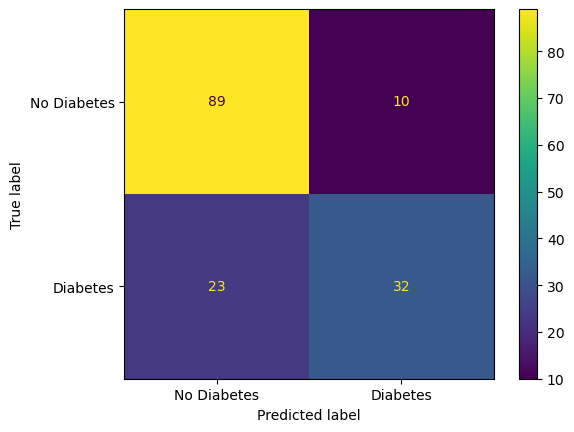

In [28]:
import matplotlib.pyplot as plt
from sklearn import metrics
plt.figure(figsize=(4,4))
cm_disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['No Diabetes','Diabetes'])
cm_disp.plot()
plt.show()

In [31]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print(TN,FP,FN,TP)

89 10 23 32


In [46]:
model_accuracy=(TP+TN)/(TN+FP+FN+TP)
print("Accuracy Score:",model_accuracy)

Accuracy Score: 0.7857142857142857


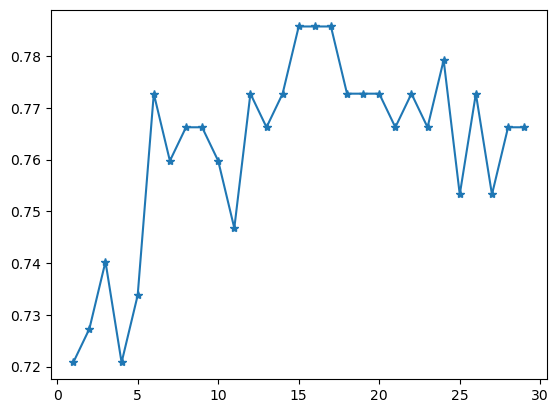

In [48]:
from sklearn.neighbors import KNeighborsClassifier
acc=[]
for i in range(1,30):
    nn=KNeighborsClassifier(n_neighbors=i)
    model=nn.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    cm=confusion_matrix(y_test,y_pred)
    TN=cm[0][0]
    FP=cm[0][1]
    FN=cm[1][0]
    TP=cm[1][1]
    model_accuracy=(TP+TN)/(TN+FP+FN+TP)
    acc.append(model_accuracy)
plt.plot(range(1,30),acc,marker='*')
plt.show()

In [49]:
from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(y_test,y_pred))

Accuracy Score: 0.7662337662337663


# Error Rate

In [52]:
error_rate=1-(accuracy_score(y_test,y_pred))
print("Error Rate:",error_rate)

Error Rate: 0.23376623376623373


In [54]:
error_rate=(FP+FN)/(TN+FP+FN+TP)
print("Error Rate:",error_rate)

Error Rate: 0.23376623376623376


# Sensitivity

In [68]:
print("Sensitivity:",(TP)/(TP+FN))

Sensitivity: 0.5272727272727272


In [69]:
from sklearn.metrics import recall_score
print("Sensitivity:",recall_score(y_test,y_pred))

Sensitivity: 0.5272727272727272


# Specificity

In [70]:
print("Specificity",(TN)/(TN+FP))

Specificity 0.898989898989899


In [71]:
from sklearn.metrics import recall_score
print("Specificity:",recall_score(y_test,y_pred,pos_label=0))

Specificity: 0.898989898989899


# Precision Score

In [72]:
print("Precision Score:",(TP)/(TP+FP))

Precision Score: 0.7435897435897436


In [73]:
from sklearn.metrics import precision_score
print("Precision Score:",precision_score(y_test,y_pred))

Precision Score: 0.7435897435897436


In [1]:
import pandas as pd
df=pd.read_csv("tshirt.csv")
df

,Height,Wight,Size
0,158,58,M
1,158,59,M
2,158,63,M
3,160,59,M
4,160,60,M
5,163,60,M
6,163,61,M
7,160,64,L
8,163,64,L
9,165,61,L


In [3]:
df.columns

Index(['Height', 'Wight', 'Size'], dtype='object')

In [5]:
x=df[['Height', 'Wight']]
y=df[ 'Size']
print(x.shape)
print(y.shape)

(18, 2)
(18,)


In [9]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=5)
model.fit(x,y)
y_pred=model.predict(x)
print(y_pred)
diff=pd.DataFrame({"Actual":y,"Predicted":y_pred})
diff

['M' 'M' 'M' 'M' 'M' 'M' 'L' 'M' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L']


,Actual,Predicted
0,M,M
1,M,M
2,M,M
3,M,M
4,M,M
5,M,M
6,M,L
7,L,M
8,L,L
9,L,L


In [17]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,y_pred)
print(cm)

[[10  1]
 [ 1  6]]


In [12]:
diff.to_excel("tshirt_data.xlsx")

<Figure size 400x400 with 0 Axes>

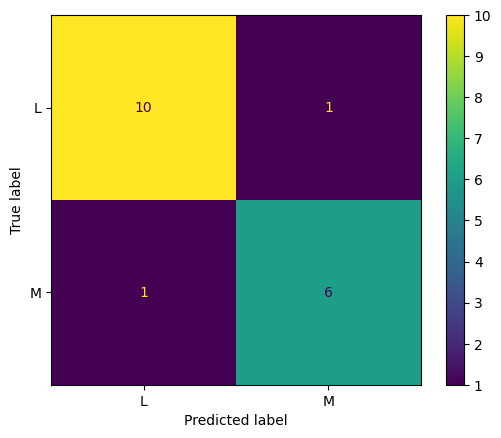

In [20]:
import matplotlib.pyplot as plt
from sklearn import metrics
plt.figure(figsize=(4,4))
cm_disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['L','M'])
cm_disp.plot()
plt.show()

In [14]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print(TN,FP,FN,TP)

10 1 1 6


In [15]:
from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(y,y_pred))

Accuracy Score: 0.8888888888888888


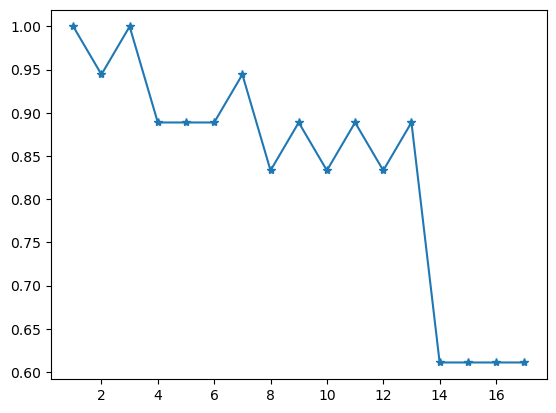

In [24]:
from sklearn.neighbors import KNeighborsClassifier
acc=[]
for i in range(1,18):
    nn=KNeighborsClassifier(n_neighbors=i)
    model=nn.fit(x,y)
    y_pred=model.predict(x)
    cm=confusion_matrix(y,y_pred)
    TN=cm[0][0]
    FP=cm[0][1]
    FN=cm[1][0]
    TP=cm[1][1]
    model_accuracy=(TP+TN)/(TN+FP+FN+TP)
    acc.append(model_accuracy)
plt.plot(range(1,18),acc,marker='*')
plt.show()

In [27]:
import pandas as pd
df=pd.read_csv("AptitudeCommunication.csv")
df

,Name,Aptitude,Communication,Class
0,Karuna,2,5.0,Speaker
1,Bhavan,2,6.0,Speaker
2,Gaurav,7,6.0,Leader
3,Parul,7,2.5,Intel
4,Dinesh,8,6.0,Leader
5,Jani,4,7.0,Speaker
6,Bobby,5,3.0,Intel
7,Parimal,3,5.5,Speaker
8,Govind,8,3.0,Intel
9,Sushant,6,5.5,Leader


In [30]:
df.drop(columns=['Name'],inplace=True)

KeyError: "['Name'] not found in axis"

In [32]:
df

,Aptitude,Communication,Class
0,2,5.0,Speaker
1,2,6.0,Speaker
2,7,6.0,Leader
3,7,2.5,Intel
4,8,6.0,Leader
5,4,7.0,Speaker
6,5,3.0,Intel
7,3,5.5,Speaker
8,8,3.0,Intel
9,6,5.5,Leader


In [33]:
df.columns

Index(['Aptitude', 'Communication', 'Class'], dtype='object')

In [35]:
x=df[['Aptitude', 'Communication']]
y=df['Class']
print(x.shape)
print(y.shape)

(14, 2)
(14,)


In [36]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=5)
model.fit(x,y)
y_pred=model.predict(x)
print(y_pred)
diff=pd.DataFrame({"Actual":y,"Predicted":y_pred})
diff

['Speaker' 'Speaker' 'Leader' 'Intel' 'Leader' 'Speaker' 'Intel' 'Speaker'
 'Intel' 'Leader' 'Intel' 'Leader' 'Intel' 'Leader']


,Actual,Predicted
0,Speaker,Speaker
1,Speaker,Speaker
2,Leader,Leader
3,Intel,Intel
4,Leader,Leader
5,Speaker,Speaker
6,Intel,Intel
7,Speaker,Speaker
8,Intel,Intel
9,Leader,Leader


In [37]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,y_pred)
print(cm)

[[5 0 0]
 [0 5 0]
 [0 0 4]]


<Figure size 400x400 with 0 Axes>

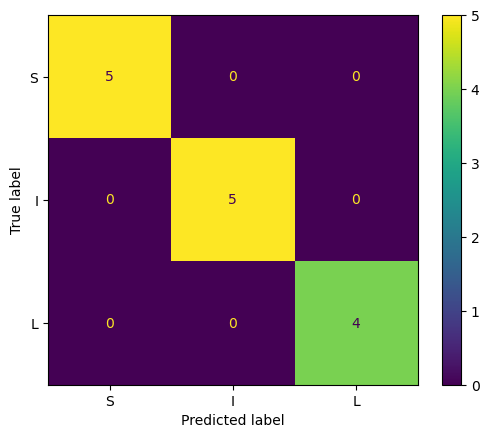

In [38]:
import matplotlib.pyplot as plt
from sklearn import metrics
plt.figure(figsize=(4,4))
cm_disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['S','I','L'])
cm_disp.plot()
plt.show()

In [39]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print(TN,FP,FN,TP)

5 0 0 5


In [40]:
from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(y,y_pred))

Accuracy Score: 1.0


# Decision Tree

In [43]:
import pandas as pd
df=pd.read_csv('DecisionTree_Sports.csv')
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,Sunny,Hot,High,Weak,No
1,Day 2,Sunny,Hot,High,Strong,No
2,Day 3,Cloudy,Hot,High,Weak,Yes
3,Day 4,Rain,Mild,High,Weak,Yes
4,Day 5,Rain,Cool,Normal,Weak,Yes
5,Day 6,Rain,Cool,Normal,Strong,No
6,Day 7,Cloudy,Cool,Normal,Strong,Yes
7,Day 8,Sunny,Mild,High,Weak,No
8,Day 9,Sunny,Cool,Normal,Weak,Yes
9,Day 10,Rain,Mild,Normal,Weak,Yes


In [45]:
import pandas as pd
df=pd.read_csv('DecisionTreeDataset -Num.csv')
df

,CGPA,Communication,Apptitude,Programming Skill,Job Offered
0,2,1,1,1,1
1,1,1,1,1,1
2,0,0,0,1,0
3,0,1,0,0,0
4,2,1,1,0,1
5,2,1,1,1,1
6,1,0,0,0,0
7,1,0,0,1,0
8,2,0,1,1,1
9,1,1,1,1,1


In [47]:
df.columns

Index(['CGPA', 'Communication', 'Apptitude', 'Programming Skill',
       'Job Offered'],
      dtype='object')

In [48]:
x=df[['CGPA', 'Communication', 'Apptitude', 'Programming Skill']]
y=df['Job Offered']
print(x.shape)
print(y.shape)

(18, 4)
(18,)


In [50]:
from sklearn.tree import DecisionTreeClassifier
tree=DecisionTreeClassifier(criterion="entropy")
tree.fit(x,y)
y_pred=tree.predict(x)
print(y_pred)
diff=pd.DataFrame({"Actual":y,"Predicted":y_pred})
diff

[1 1 0 0 1 1 0 0 1 1 0 0 1 0 0 0 0 1]


,Actual,Predicted
0,1,1
1,1,1
2,0,0
3,0,0
4,1,1
5,1,1
6,0,0
7,0,0
8,1,1
9,1,1


In [3]:
import pandas as pd
df=pd.read_csv("Categorized_Sports_Data.csv")
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,1,0,1,0
1,Day 2,2,1,0,0,0
2,Day 3,0,1,0,1,1
3,Day 4,1,2,0,1,1
4,Day 5,1,0,1,1,1
5,Day 6,1,0,1,0,0
6,Day 7,0,0,1,0,1
7,Day 8,2,2,0,1,0
8,Day 9,2,0,1,1,1
9,Day 10,1,2,1,1,1


In [12]:
import pandas as pd
df=pd.read_csv("DecisionTree_Sports.csv")
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,Sunny,Hot,High,Weak,No
1,Day 2,Sunny,Hot,High,Strong,No
2,Day 3,Cloudy,Hot,High,Weak,Yes
3,Day 4,Rain,Mild,High,Weak,Yes
4,Day 5,Rain,Cool,Normal,Weak,Yes
5,Day 6,Rain,Cool,Normal,Strong,No
6,Day 7,Cloudy,Cool,Normal,Strong,Yes
7,Day 8,Sunny,Mild,High,Weak,No
8,Day 9,Sunny,Cool,Normal,Weak,Yes
9,Day 10,Rain,Mild,Normal,Weak,Yes


In [13]:
import numpy as np
df['Weather']=np.where(df['Weather']=='Cloudy',0,np.where(df['Weather']=='Rain',1,2))
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,Hot,High,Weak,No
1,Day 2,2,Hot,High,Strong,No
2,Day 3,0,Hot,High,Weak,Yes
3,Day 4,1,Mild,High,Weak,Yes
4,Day 5,1,Cool,Normal,Weak,Yes
5,Day 6,1,Cool,Normal,Strong,No
6,Day 7,0,Cool,Normal,Strong,Yes
7,Day 8,2,Mild,High,Weak,No
8,Day 9,2,Cool,Normal,Weak,Yes
9,Day 10,1,Mild,Normal,Weak,Yes


In [15]:
df['Temperature']=np.where(df['Temperature']=='Cool',0,np.where(df['Temperature']=='Hot',1,2))
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,1,High,Weak,No
1,Day 2,2,1,High,Strong,No
2,Day 3,0,1,High,Weak,Yes
3,Day 4,1,2,High,Weak,Yes
4,Day 5,1,0,Normal,Weak,Yes
5,Day 6,1,0,Normal,Strong,No
6,Day 7,0,0,Normal,Strong,Yes
7,Day 8,2,2,High,Weak,No
8,Day 9,2,0,Normal,Weak,Yes
9,Day 10,1,2,Normal,Weak,Yes


In [16]:
df['Humidity']=np.where(df['Humidity']=='High',0,1)
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,1,0,Weak,No
1,Day 2,2,1,0,Strong,No
2,Day 3,0,1,0,Weak,Yes
3,Day 4,1,2,0,Weak,Yes
4,Day 5,1,0,1,Weak,Yes
5,Day 6,1,0,1,Strong,No
6,Day 7,0,0,1,Strong,Yes
7,Day 8,2,2,0,Weak,No
8,Day 9,2,0,1,Weak,Yes
9,Day 10,1,2,1,Weak,Yes


In [17]:
df['Wind']=np.where(df['Wind']=='Strong',0,1)
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,1,0,1,No
1,Day 2,2,1,0,0,No
2,Day 3,0,1,0,1,Yes
3,Day 4,1,2,0,1,Yes
4,Day 5,1,0,1,1,Yes
5,Day 6,1,0,1,0,No
6,Day 7,0,0,1,0,Yes
7,Day 8,2,2,0,1,No
8,Day 9,2,0,1,1,Yes
9,Day 10,1,2,1,1,Yes


In [18]:
df['Play_Sports?']=np.where(df['Play_Sports?']=='No',0,1)
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,1,0,1,0
1,Day 2,2,1,0,0,0
2,Day 3,0,1,0,1,1
3,Day 4,1,2,0,1,1
4,Day 5,1,0,1,1,1
5,Day 6,1,0,1,0,0
6,Day 7,0,0,1,0,1
7,Day 8,2,2,0,1,0
8,Day 9,2,0,1,1,1
9,Day 10,1,2,1,1,1


In [19]:
df.columns

Index(['Day', 'Weather', 'Temperature', 'Humidity', 'Wind', 'Play_Sports?'], dtype='object')

In [21]:
x=df[['Weather', 'Temperature', 'Humidity', 'Wind']]
y=df['Play_Sports?']
print(x.shape)
print(y.shape)

(14, 4)
(14,)


In [23]:
from sklearn.tree import DecisionTreeClassifier
tree=DecisionTreeClassifier(criterion='entropy')
model=tree.fit(x,y)
pred=model.predict(x)
print(pred)

[0 0 1 1 1 0 1 0 1 1 1 1 1 0]


In [26]:
from sklearn.tree import export_text
text_representation=export_text(tree)
print(text_representation)

|--- feature_0 <= 0.50
|   |--- class: 1
|--- feature_0 >  0.50
|   |--- feature_2 <= 0.50
|   |   |--- feature_0 <= 1.50
|   |   |   |--- feature_3 <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_3 >  0.50
|   |   |   |   |--- class: 1
|   |   |--- feature_0 >  1.50
|   |   |   |--- class: 0
|   |--- feature_2 >  0.50
|   |   |--- feature_3 <= 0.50
|   |   |   |--- feature_1 <= 1.00
|   |   |   |   |--- class: 0
|   |   |   |--- feature_1 >  1.00
|   |   |   |   |--- class: 1
|   |   |--- feature_3 >  0.50
|   |   |   |--- class: 1



In [27]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix
cm=confusion_matrix(y,pred)
print(cm)

[[5 0]
 [0 9]]


In [29]:
accuracy_score(y,pred)

1.0

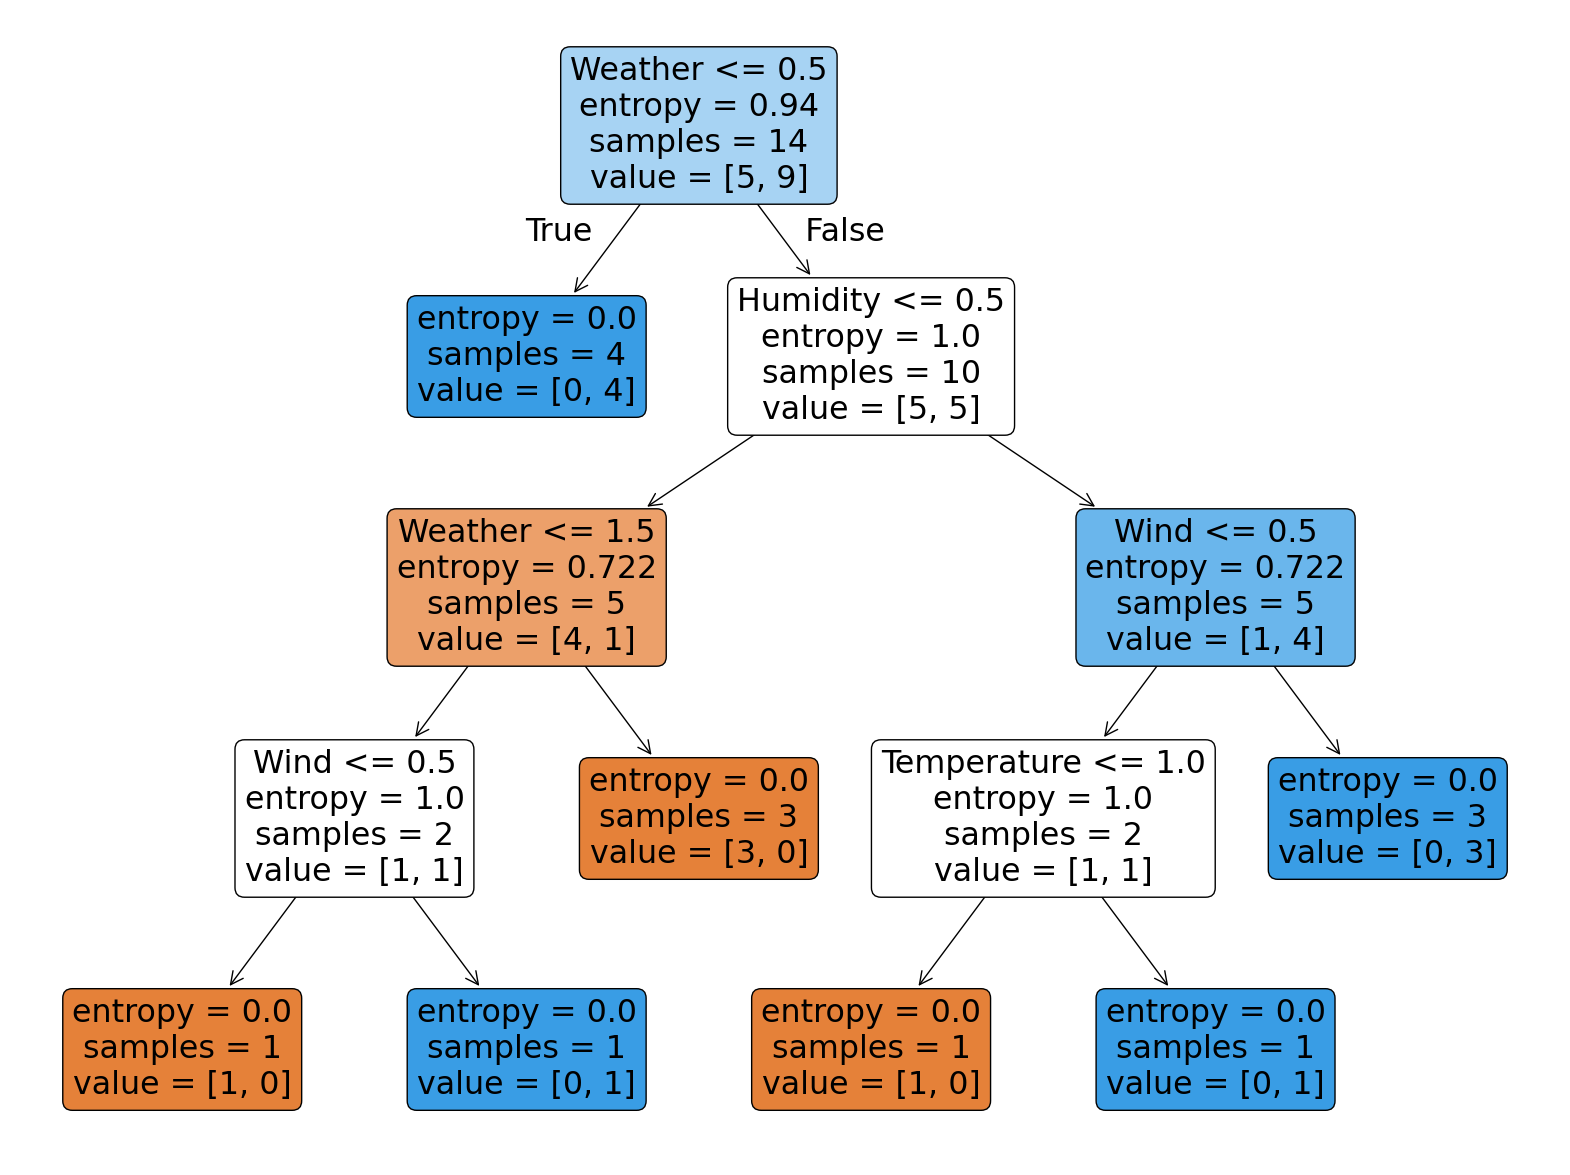

In [37]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,15))
plot_tree(tree,feature_names=x.columns,filled=True,rounded=True)
plt.show()

In [38]:
import pandas as pd
df=pd.read_csv("DecisionTreeDataset -Num.csv")
df

,CGPA,Communication,Apptitude,Programming Skill,Job Offered
0,2,1,1,1,1
1,1,1,1,1,1
2,0,0,0,1,0
3,0,1,0,0,0
4,2,1,1,0,1
5,2,1,1,1,1
6,1,0,0,0,0
7,1,0,0,1,0
8,2,0,1,1,1
9,1,1,1,1,1


In [39]:
df.columns

Index(['CGPA', 'Communication', 'Apptitude', 'Programming Skill',
       'Job Offered'],
      dtype='object')

In [40]:
x=df[['CGPA', 'Communication', 'Apptitude', 'Programming Skill']]
y=df['Job Offered']
print(x.shape)
print(y.shape)

(18, 4)
(18,)


In [41]:
from sklearn.tree import DecisionTreeClassifier
tree=DecisionTreeClassifier(criterion='entropy')
model=tree.fit(x,y)
pred=model.predict(x)
print(pred)

[1 1 0 0 1 1 0 0 1 1 0 0 1 0 0 0 0 1]


In [42]:
from sklearn.tree import export_text
text_representation=export_text(tree)
print(text_representation)

|--- feature_2 <= 0.50
|   |--- class: 0
|--- feature_2 >  0.50
|   |--- feature_1 <= 0.50
|   |   |--- feature_0 <= 1.50
|   |   |   |--- class: 0
|   |   |--- feature_0 >  1.50
|   |   |   |--- class: 1
|   |--- feature_1 >  0.50
|   |   |--- class: 1



In [43]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix
cm=confusion_matrix(y,pred)
print(cm)

[[10  0]
 [ 0  8]]


In [44]:
accuracy_score(y,pred)

1.0

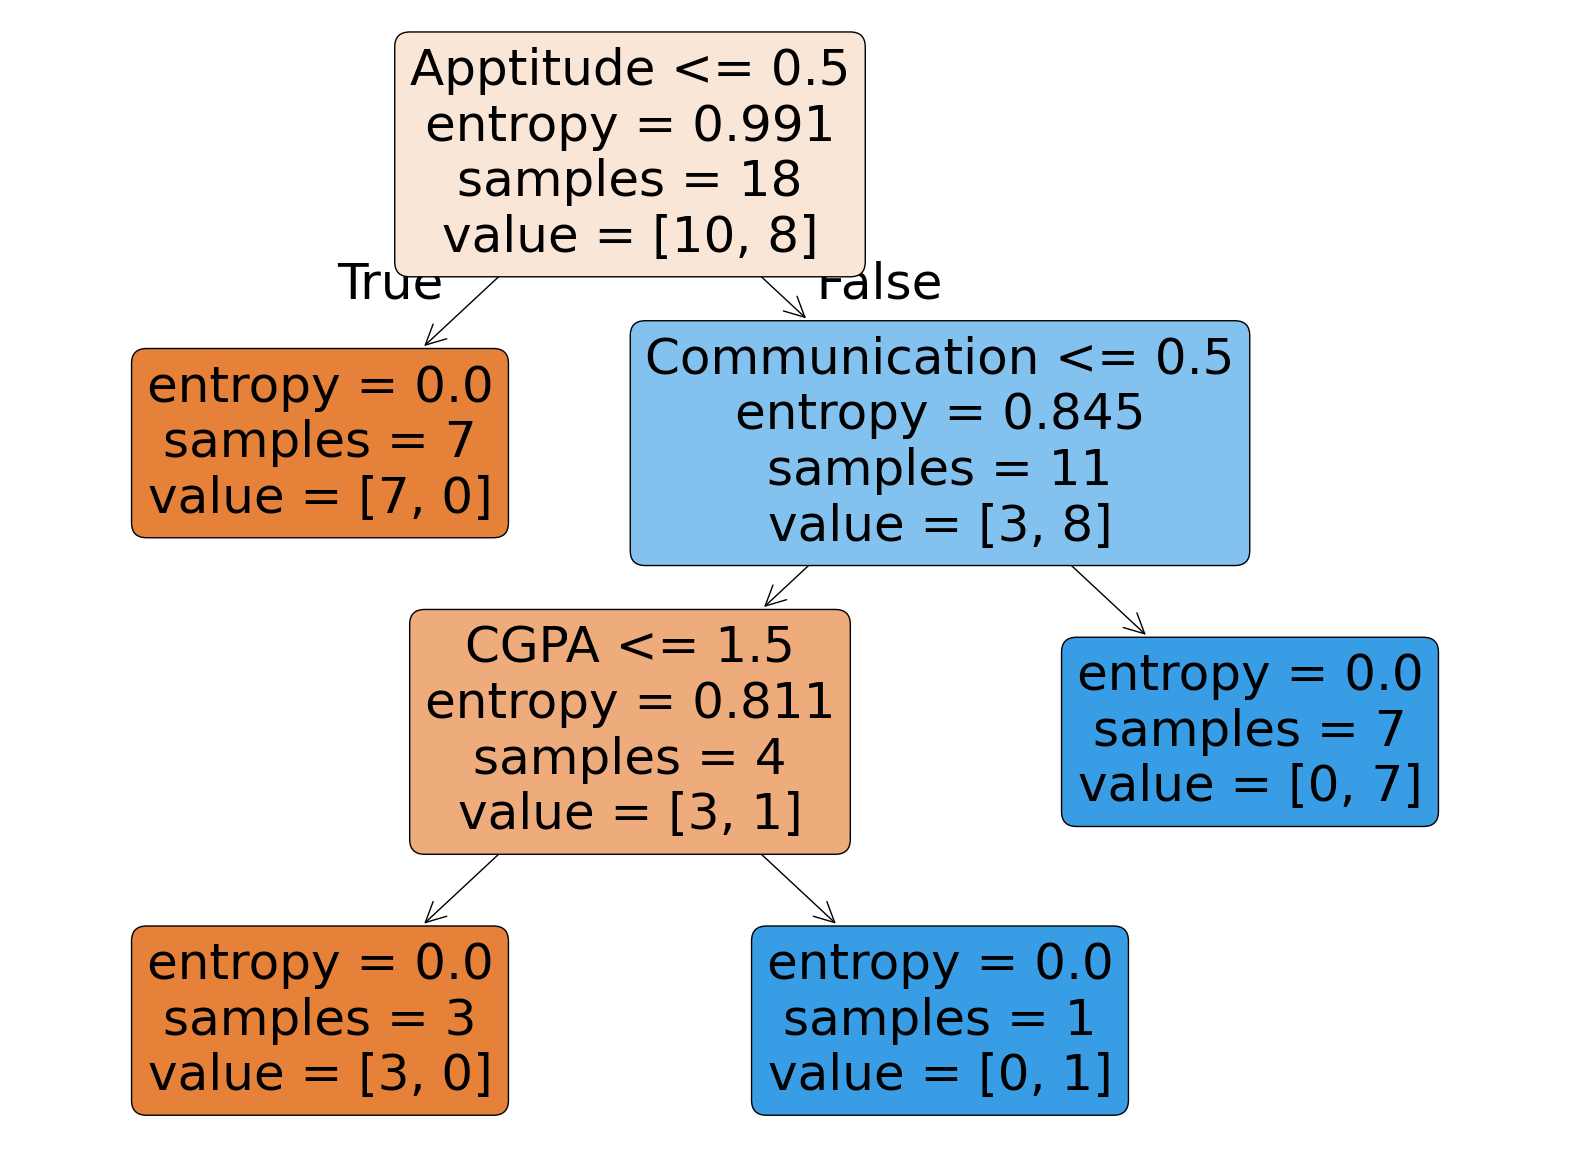

In [47]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,15))
plot_tree(tree,feature_names=x.columns,filled=True,rounded=True)
plt.show()

In [48]:
tree.get_depth()

3

In [84]:
import pandas as pd
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [85]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [86]:
x=df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age',]]
y=df['Outcome']
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [87]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [94]:
from sklearn.tree import DecisionTreeClassifier
tree=DecisionTreeClassifier(criterion='entropy',random_state=1)
model=tree.fit(x_train,y_train)
pred=model.predict(x_test)
print(pred)

[1 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 0 1 0 1 0 0 0 0 1 0 1 0 1 0 1 1 1 0
 1 0 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1 0 1 1 0 0
 0 1 1 1 0 1 1 0 0 1 0 0 1 0 1 0 0 0 0 0 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 1 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 1 0 0 1 0 0 1 0 1 0 0
 0 1 0 1 0 1]


In [95]:
from sklearn.tree import export_text
text_representation=export_text(tree)
print(text_representation)

|--- feature_1 <= 127.50
|   |--- feature_5 <= 26.45
|   |   |--- feature_5 <= 9.10
|   |   |   |--- feature_1 <= 114.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_1 >  114.50
|   |   |   |   |--- class: 1
|   |   |--- feature_5 >  9.10
|   |   |   |--- feature_6 <= 0.67
|   |   |   |   |--- class: 0
|   |   |   |--- feature_6 >  0.67
|   |   |   |   |--- feature_6 <= 0.71
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- feature_6 >  0.71
|   |   |   |   |   |--- class: 0
|   |--- feature_5 >  26.45
|   |   |--- feature_7 <= 28.50
|   |   |   |--- feature_5 <= 30.95
|   |   |   |   |--- feature_0 <= 7.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- feature_0 >  7.00
|   |   |   |   |   |--- class: 1
|   |   |   |--- feature_5 >  30.95
|   |   |   |   |--- feature_7 <= 22.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- feature_7 >  22.50
|   |   |   |   |   |--- feature_5 <= 45.40
|   |   |   |   |   |   |--- feature_5 <= 38.35
|   |   |   |   |   |

In [96]:
tree.get_depth()

14

In [97]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix
cm=confusion_matrix(y_test,pred)
print(cm)

[[78 21]
 [21 34]]


In [98]:
accuracy_score(y_test,pred)

0.7272727272727273

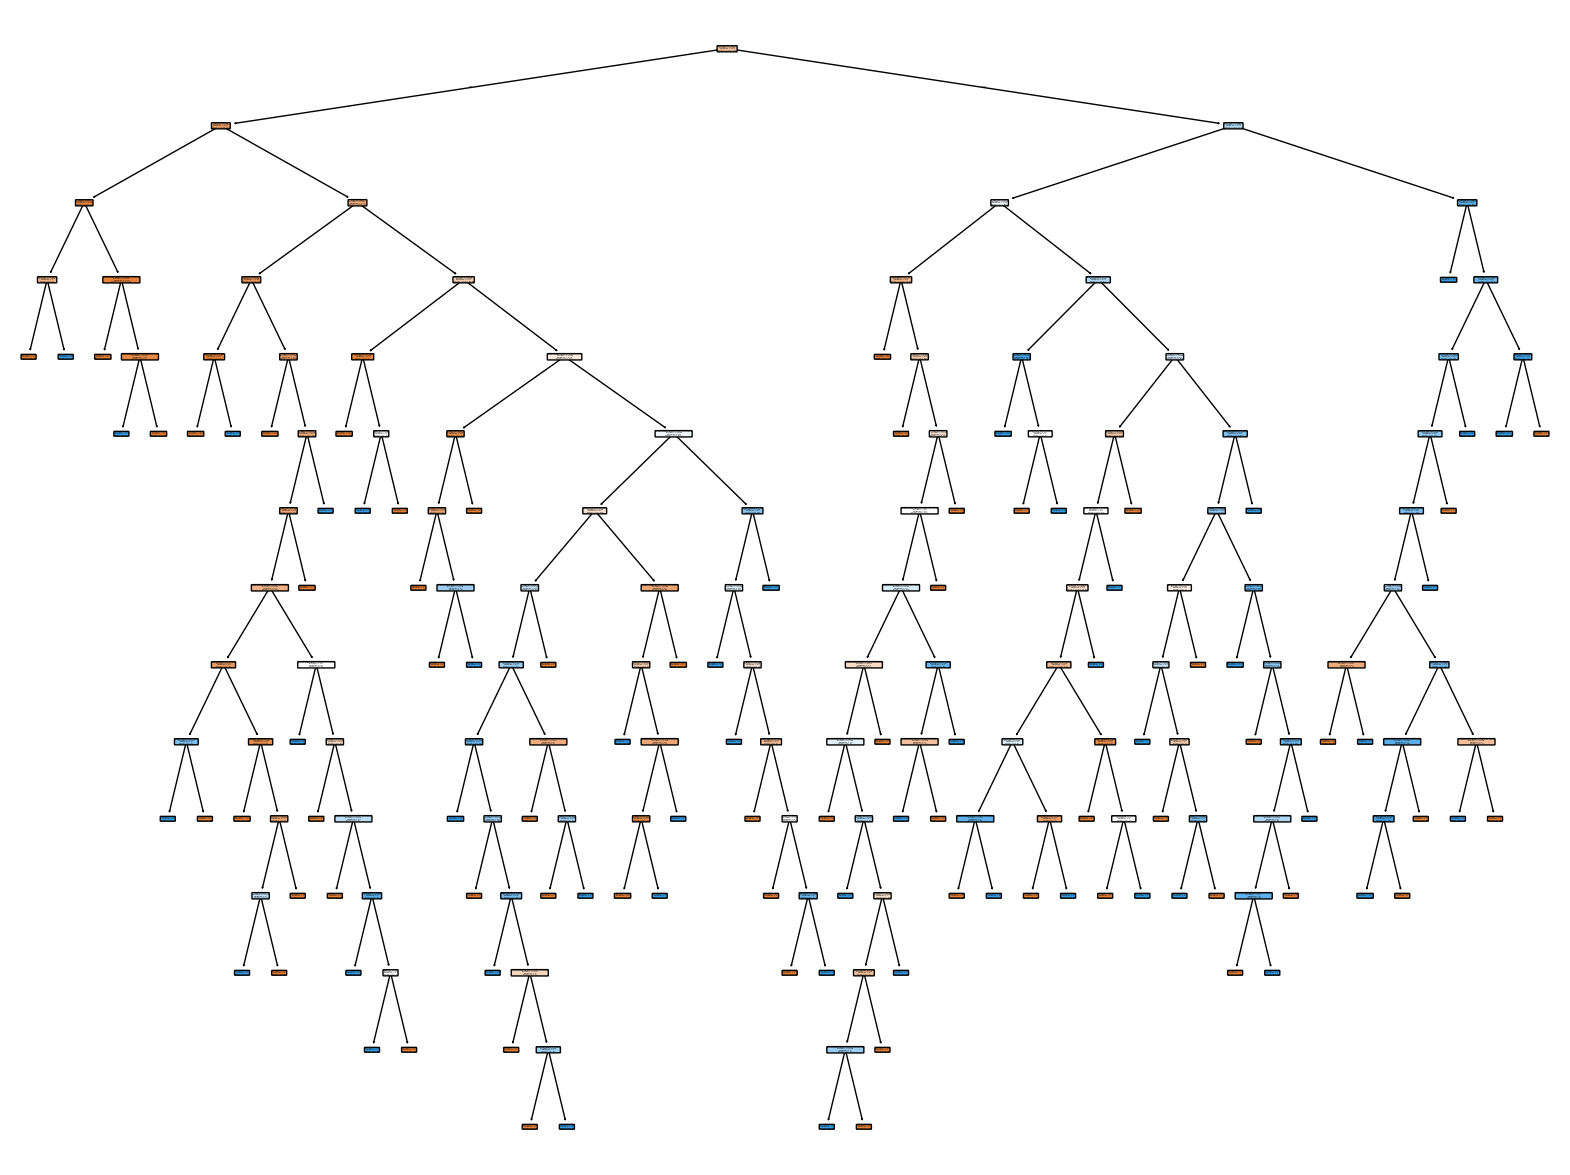

In [99]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,15))
plot_tree(tree,feature_names=x.columns,filled=True,rounded=True)
plt.show()

# Random Forest

In [100]:
import pandas as pd
df=pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [104]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [105]:
df['Age']=df['Age'].fillna(df['Age'].median)

In [107]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [108]:
import numpy as np
df['Sex']=np.where(df['Sex']=='male',1,0)

In [110]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,<bound method Series.median of 0 22.0\n1 ...,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.0000,C148,C


In [111]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [116]:
x=df[['Pclass', 'Sex', 'Age', 'SibSp','Parch', 'Fare']]
y=df['Survived']
print(x.shape)
print(y.shape)

(891, 6)
(891,)


In [117]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 6)
(179, 6)
(712,)
(179,)


In [128]:
from sklearn.ensemble import RandomForestClassifier
classifier=RandomForestClassifier(criterion='entropy',n_estimators=100,random_state=42)
classifier.fit(x_train,y_train)
pred=classifier.predict(x_test)
print(pred)

TypeError: float() argument must be a string or a real number, not 'method'

In [122]:
from sklearn.metrics import accuracy_score,confusion_matrix
cm=confusion_matrix(y_test,pred)
print(cm)

ValueError: Found input variables with inconsistent numbers of samples: [179, 154]

In [127]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
tree=classifier.estimators_[0]
plot_tree(tree,feature_name=x.columns,filled=True,rounded=True)
plt.show()

AttributeError: 'RandomForestClassifier' object has no attribute 'estimators_'

<Figure size 2000x1000 with 0 Axes>